Importing libraries and loading the dataset

In [270]:
import numpy as np
import pandas as pd

attrition_df = pd.read_csv('hr_attrition_dataset.csv')

Drop duplicates and check data info

In [271]:
attrition_df = attrition_df.drop_duplicates()
attrition_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   employee_id                  15000 non-null  str    
 1   age                          15000 non-null  int64  
 2   gender                       15000 non-null  str    
 3   marital_status               15000 non-null  str    
 4   education                    15000 non-null  str    
 5   education_field              15000 non-null  str    
 6   num_companies_worked         15000 non-null  int64  
 7   department                   15000 non-null  str    
 8   job_role                     15000 non-null  str    
 9   job_level                    15000 non-null  int64  
 10  employment_type              15000 non-null  str    
 11  years_at_company             15000 non-null  int64  
 12  years_in_current_role        15000 non-null  int64  
 13  total_working_years        

Data Type Casting for Performance Rating and Job Satisfaction

In [272]:
for col in ['job_satisfaction', 'performance_rating']:
    attrition_df[col] = attrition_df[col].round()

Null value imputation for performance_rating based on Department, Job Role, Job Level, Employment Type, Manager Rating, Skills Growth Opportunities

In [273]:
rating_hierarchy = [
    ['department', 'job_role', 'job_level', 'employment_type', 'manager_rating', 'skills_growth_opportunities'],
    ['department', 'job_role', 'job_level', 'employment_type', 'manager_rating'],
]

for group_cols in rating_hierarchy:
    attrition_df['performance_rating'] = attrition_df['performance_rating'].fillna(
        attrition_df.groupby(group_cols)['performance_rating'].transform('mean')
    )

attrition_df['performance_rating'] = attrition_df['performance_rating'].fillna(attrition_df['manager_rating'])

Null value imputation for Monthly Income Based on Department, Job Role, Job Level, Employment Type

In [274]:
group_cols_monthly_income = ['department', 'job_role','job_level','employment_type']

attrition_df['monthly_income'] = attrition_df['monthly_income'].fillna(
    attrition_df.groupby(group_cols_monthly_income)['monthly_income'].transform('mean')
)

Null value imputation for job satisfaction based on Department, Job Role, Job Level, Employment Type, Work Life Balance

In [275]:

import numpy as np
import math

def custom_round(x):
    if pd.isna(x):
        return np.nan           
    decimal = x - math.floor(x)
    if decimal < 0.5:
        return math.floor(x)
    else:
        return math.ceil(x)


attrition_df['job_satisfaction'] = attrition_df['job_satisfaction'].apply(custom_round)

group_cols_job_satisfaction = ['department', 'job_role','job_level','employment_type','work_life_balance']
attrition_df['job_satisfaction'] = attrition_df['job_satisfaction'].fillna(
    attrition_df.groupby(group_cols_job_satisfaction)['job_satisfaction'].transform('mean').round(2)
)
attrition_df['job_satisfaction'] = attrition_df['job_satisfaction'].fillna(attrition_df['work_life_balance']).round(2)

attrition_df['job_satisfaction']  = attrition_df['job_satisfaction'].apply(custom_round)

Creation of age groups based on categories: Gen Z, Early Career, Mid-Career, Experienced, Late Career

In [276]:
bins = [21, 25, 35, 45, 55, 65]
labels = ['Fresher', 'Early-Career', 'Mid-Career', 'Experienced', 'Late-Career']

attrition_df['age_group'] = pd.cut(attrition_df['age'], bins=bins, labels=labels)

Creation of Average Tenure per Company based on Total Working Years and Number of Companies Worked

In [277]:
attrition_df['avg_tenure_per_company'] = (
    attrition_df['total_working_years'] / attrition_df['num_companies_worked'].replace(0, 1)
)
attrition_df['avg_tenure_per_company'] = attrition_df['avg_tenure_per_company'].round(2)

Creation of Role Stagnation Ratio based on Years in Current Role and Years at Company

In [278]:
attrition_df['role_stagnation_ratio'] = (
    attrition_df['years_in_current_role'] / attrition_df['years_at_company'].replace(0, 1)
)

attrition_df['role_stagnation_ratio'] = attrition_df['role_stagnation_ratio'].round(2)

Creation of Promotion Velocity based on Years at Company and Promotions in Last 5 Years

In [279]:
attrition_df['promotion_velocity'] = (
    attrition_df['years_at_company'] / (attrition_df['promotions_last_5years'])
).round(2)
attrition_df['promotion_velocity'] = attrition_df['promotion_velocity'].replace([np.inf, np.nan], 0)

Creation of Total Overtime Hours based on Overtime Hours per Week and Years in Current Role

In [280]:
attrition_df['total_overtime_hours'] = (
    attrition_df['overtime_hours_per_week'] * attrition_df['years_in_current_role'] * 52
)


Creation of Overtime Category based on Total Overtime hours

In [281]:
def calculate_overtime_category(row):
    if row['total_overtime_hours'] > 4000:
        return 'High-Overwork'
    elif row['total_overtime_hours'] > 1000 and row['total_overtime_hours'] <= 4000:
        return 'Medium-Overwork'
    else:
        return 'Low-Overwork'
    

attrition_df['overtime_category'] = attrition_df.apply(calculate_overtime_category, axis=1)

Creation of Burnout Risk Score based on Overtime Hours per week, Overtime Paid Eligible

In [282]:
high_ot_threshold = 10

attrition_df['burnout_risk_flag'] = (
    (attrition_df['overtime_hours_per_week'] > high_ot_threshold) & 
    (attrition_df['overtime_paid_eligible'] == 'No')
)

Creation of Income group based on Monthly Income 

In [283]:

attrition_df['income_group'] = pd.cut(attrition_df['monthly_income'], bins=3, labels=['Low-Income', 'Medium-Income', 'High-Income'])
display(attrition_df.head())

,employee_id,age,gender,marital_status,education,education_field,num_companies_worked,department,job_role,job_level,...,remote_work_days_per_week,attrition,age_group,avg_tenure_per_company,role_stagnation_ratio,promotion_velocity,total_overtime_hours,overtime_category,burnout_risk_flag,income_group
0,EMP_00000001,35,Male,Married,Bachelor,Business,1,IT,Junior,4,...,2,Yes,Early-Career,4.00,1.00,1.0,2652,Medium-Overwork,True,Medium-Income
1,EMP_00000002,44,Male,Divorced,Bachelor,Arts,1,Sales,Junior,2,...,2,Yes,Mid-Career,6.00,0.67,0.0,416,Low-Overwork,False,Low-Income
2,EMP_00000003,38,Female,Single,Bachelor,Business,3,Finance,Senior,5,...,0,No,Mid-Career,6.33,3.00,0.0,156,Low-Overwork,False,Low-Income
3,EMP_00000004,40,Male,Single,Master,Business,5,Sales,Junior,3,...,1,No,Mid-Career,0.80,3.00,0.0,1560,Medium-Overwork,False,Low-Income
4,EMP_00000005,32,Male,Single,Master,Technical,1,Sales,Junior,3,...,0,No,Early-Career,3.00,1.50,0.0,156,Low-Overwork,False,Low-Income


In [284]:
attrition_df['income_age_group'] = (
    attrition_df['income_group'].astype(str) + '_' + attrition_df['age_group'].astype(str)
)

In [285]:
result = attrition_df.isnull().sum()
display(result)

employee_id                    0
age                            0
gender                         0
marital_status                 0
education                      0
education_field                0
num_companies_worked           0
department                     0
job_role                       0
job_level                      0
employment_type                0
years_at_company               0
years_in_current_role          0
total_working_years            0
monthly_income                 0
percent_salary_hike            0
stock_option_level             0
bonus_eligible                 0
overtime_paid_eligible         0
business_travel                0
work_life_balance              0
job_satisfaction               0
environment_satisfaction       0
relationship_satisfaction      0
overtime_hours_per_week        0
performance_rating             0
training_times_last_year       0
promotions_last_5years         0
years_since_last_promotion     0
skills_growth_opportunities    0
manager_ra

In [286]:
import pandas as pd
from scipy.stats import chi2_contingency

cont_table = pd.crosstab(attrition_df['income_age_group'], attrition_df['attrition'])
print(cont_table)


chi2, p_value, dof, expected = chi2_contingency(cont_table)

print('Chi-square:', chi2)
print('Degrees of freedom:', dof)
print('p-value:', p_value)

print('Null Hypothesis: There is no significant association between income_age_group and attrition.')

if p_value < 0.05:
    print('Reject the null hypothesis: There is a significant association between income_age_group and attrition.')
else:
    print('Fail to reject the null hypothesis: There is no significant association between income_age_group and attrition.')

attrition                     No   Yes
income_age_group                      
High-Income_Early-Career       0     1
High-Income_Late-Career        0     1
High-Income_Mid-Career         1     1
Low-Income_Early-Career     2763  1660
Low-Income_Experienced      1646   945
Low-Income_Fresher          1031   648
Low-Income_Late-Career       317   220
Low-Income_Mid-Career       3399  2006
Medium-Income_Early-Career    75    46
Medium-Income_Experienced     47    20
Medium-Income_Fresher         21    17
Medium-Income_Late-Career      8     2
Medium-Income_Mid-Career      85    40
Chi-square: 13.975364180277712
Degrees of freedom: 12
p-value: 0.3022842461252805
Null Hypothesis: There is no significant association between income_age_group and attrition.
Fail to reject the null hypothesis: There is no significant association between income_age_group and attrition.


In [287]:
from scipy.stats import ttest_ind

yes_promotion_group = attrition_df[attrition_df['attrition'] == 'Yes']['promotion_velocity']
no_promotion_group = attrition_df[attrition_df['attrition'] == 'No']['promotion_velocity']

t_stat, p_value = ttest_ind(yes_promotion_group, no_promotion_group, equal_var=False)

print('T-statistic:', t_stat)
print('P-value:', p_value)

if p_value < 0.05:
    print('Reject the null hypothesis: Promotion velocity is significantly influenced by attrition status.')
else:
    print('Fail to reject the null hypothesis: Promotion velocity is not significantly influenced by attrition status.')

T-statistic: -11.209454198927682
P-value: 4.9903180808001534e-29
Reject the null hypothesis: Promotion velocity is significantly influenced by attrition status.


In [288]:
result = attrition_df.groupby(['promotion_velocity','attrition']).size().rename('count').reset_index()
display(result)

,promotion_velocity,attrition,count
0,0.00,No,4847
1,0.00,Yes,3527
2,0.33,No,68
3,0.33,Yes,62
4,0.50,No,215
...,...,...,...
94,23.00,Yes,2
95,24.00,No,2
96,24.00,Yes,1
97,25.00,No,3


<Figure size 1400x800 with 0 Axes>

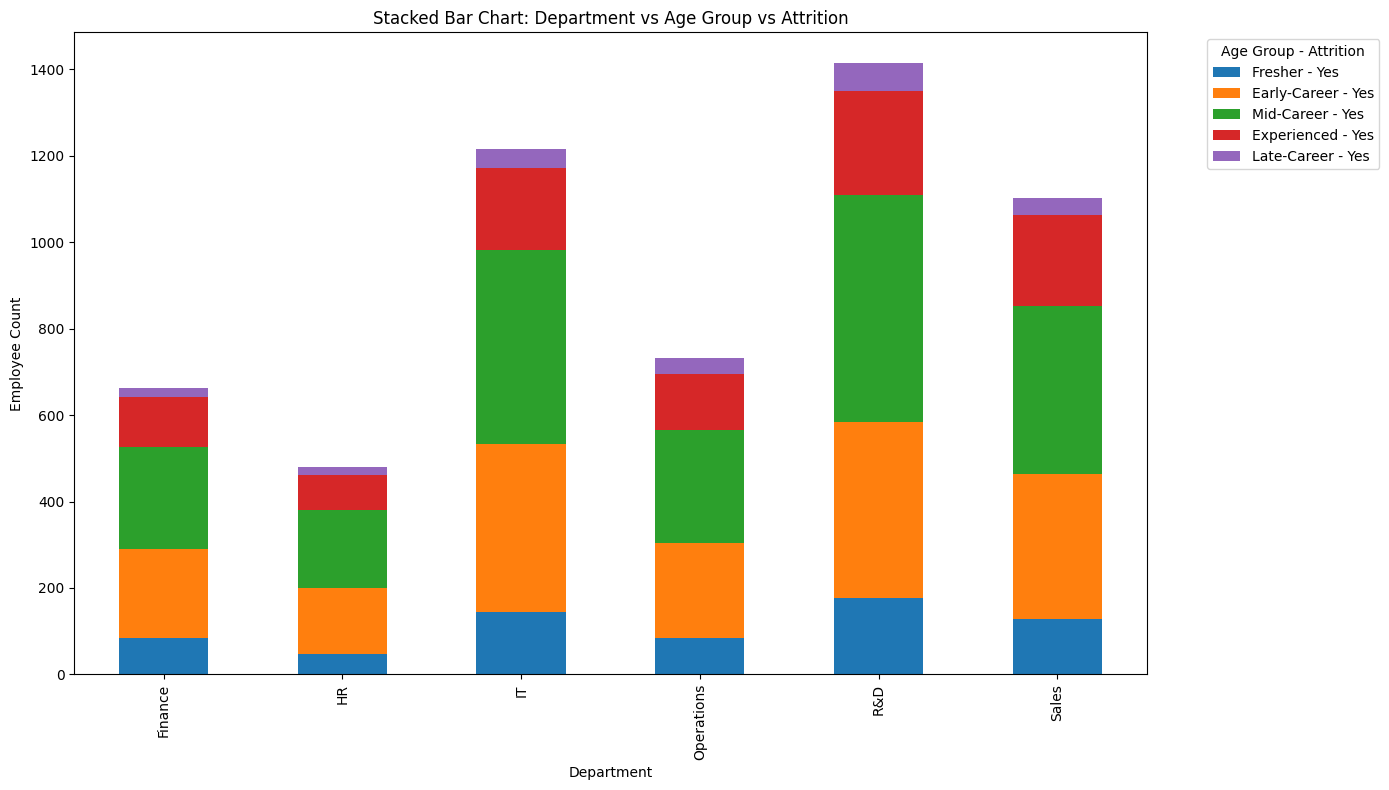

In [289]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Group the data
grouped = (
    attrition_df[attrition_df['attrition'] != 'No']
    .groupby(['department', 'age_group', 'attrition'])
    .size()
    .reset_index(name='count')
)

# 2. Pivot the data into a stacked-bar–friendly format
pivot_df = grouped.pivot_table(
    index=['department', 'age_group'],
    columns='attrition',
    values='count',
    fill_value=0
)

# 3. Unstack age_group so each age_group becomes a stacked layer
stack_df = pivot_df.unstack(level='age_group')

# 4. Flatten column names: (attrition, age_group) → "age_group - attrition"
stack_df.columns = [f'{age_group} - {attr}' for attr, age_group in stack_df.columns]

# 5. Plot the stacked bar chart
plt.figure(figsize=(14, 8))
stack_df.plot(kind='bar', stacked=True, figsize=(14, 8))

plt.title('Stacked Bar Chart: Department vs Age Group vs Attrition')
plt.xlabel('Department')
plt.ylabel('Employee Count')
plt.legend(title='Age Group - Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


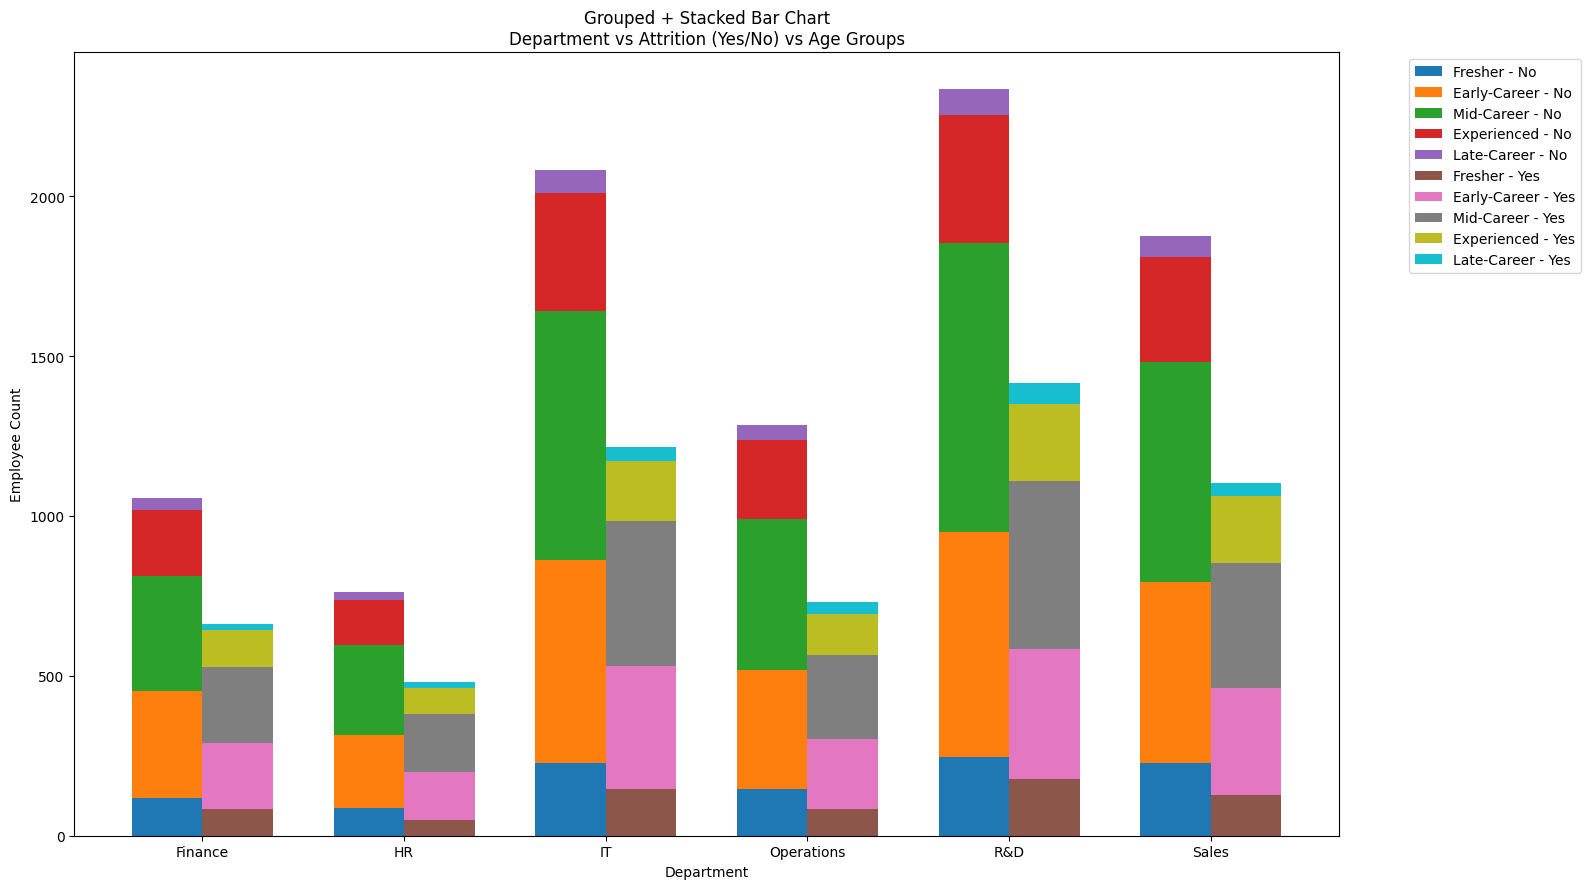

In [290]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

grouped = (
    attrition_df
    .groupby(['department', 'attrition', 'age_group'])
    .size()
    .reset_index(name='count')
)

pivot_df = grouped.pivot_table(
    index=['department', 'attrition'],
    columns='age_group',
    values='count',
    fill_value=0
).reset_index()

departments = pivot_df['department'].unique()
age_groups = pivot_df.columns[2:]


x = np.arange(len(departments))            
width = 0.35                               

plt.figure(figsize=(16, 9))

bottom_no = np.zeros(len(departments))
for age in age_groups:
    values = pivot_df[pivot_df['attrition'] == 'No'][age].values
    plt.bar(x - width/2, values, width, bottom=bottom_no, label=f'{age} - No')
    bottom_no += values


bottom_yes = np.zeros(len(departments))
for age in age_groups:
    values = pivot_df[pivot_df['attrition'] == 'Yes'][age].values
    plt.bar(x + width/2, values, width, bottom=bottom_yes, label=f'{age} - Yes')
    bottom_yes += values

plt.xticks(x, departments)
plt.xlabel("Department")
plt.ylabel("Employee Count")
plt.title("Grouped + Stacked Bar Chart\nDepartment vs Attrition (Yes/No) vs Age Groups")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [294]:
result = attrition_df.groupby(['age_group','job_satisfaction','attrition']).size().rename('count').reset_index()
display(result)

,age_group,job_satisfaction,attrition,count
0,Fresher,1,No,35
1,Fresher,1,Yes,41
2,Fresher,2,No,177
3,Fresher,2,Yes,220
4,Fresher,3,No,506
5,Fresher,3,Yes,258
6,Fresher,4,No,334
7,Fresher,4,Yes,146
8,Early-Career,1,No,97
9,Early-Career,1,Yes,115
